In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve

In [12]:
df1 = pd.read_excel(r'D:/Learning/Projects/E-commerce_customer_Churn_analysis/data/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel(r'D:/Learning/Projects/E-commerce_customer_Churn_analysis/data/online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df1, df2], ignore_index=True)

In [59]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [60]:
df.shape

(1067371, 8)

In [61]:
df['Customer ID'].nunique()

5942

In [62]:
df["InvoiceDate"].min()

Timestamp('2009-12-01 07:45:00')

In [63]:
df["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [64]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,1067371.0,53628.0,537434.0,1350.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,NaN,NaN,NaN,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,NaN,NaN,NaN,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [66]:
null_customers = df["Customer ID"].isnull().sum()
null_customers

243007

In [67]:
total_customers = df["Customer ID"].count()
total_customers

824364

In [68]:
(null_customers/total_customers) * 100

29.478118889228544

In [69]:
df.sample(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
988278,576014,35970,ZINC FOLKART SLEIGH BELLS,3,2011-11-13 14:29:00,1.69,17218.0,United Kingdom
635310,545661,22653,BUTTON BOX,10,2011-03-04 14:41:00,1.95,15358.0,United Kingdom
823505,C562969,21987,PACK OF 6 SKULL PAPER CUPS,-12,2011-08-11 10:58:00,0.65,12610.0,Italy
593390,541848,79191D,RETRO PLASTIC DAISY TRAY,1,2011-01-23 13:31:00,0.85,17611.0,United Kingdom
451397,532306,22396,MAGNETS PACK OF 4 RETRO PHOTO,1,2010-11-11 14:29:00,1.25,12637.0,France
967386,574657,22993,SET OF 4 PANTRY JELLY MOULDS,3,2011-11-06 11:43:00,1.25,13772.0,United Kingdom
753290,556908,22791,T-LIGHT GLASS FLUTED ANTIQUE,24,2011-06-15 13:23:00,1.25,18165.0,United Kingdom
397658,527428,21822,GLITTER CHRISTMAS TREE WITH BELLS,6,2010-10-17 16:17:00,1.95,16283.0,United Kingdom
838832,C564488,23090,VINTAGE GLASS T-LIGHT HOLDER,-9,2011-08-25 14:12:00,0.83,16859.0,United Kingdom
85766,497358,21181,PLEASE ONE PERSON METAL SIGN,2,2010-02-08 17:25:00,2.10,14606.0,United Kingdom


In [70]:
df_clean = df.dropna()

In [71]:
df_clean.shape

(824364, 8)

In [72]:
df_clean["Customer ID"].isnull().sum()

0

In [73]:
neg_quantity = (df_clean['Quantity'] <= 0)

In [74]:
neg_quantity.sum()

18744

In [75]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [76]:
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

In [77]:
df_clean['Invoice'].astype(str).str.startswith('C').sum()

0

In [78]:
neg_price = df_clean['Price'] <= 0

In [79]:
neg_price.sum()

71

In [80]:
df_clean = df_clean[df_clean['Price'] > 0]

In [81]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

In [82]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [83]:
df_clean.shape

(805549, 9)

In [84]:
df_clean.sample(15)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
110034,499967,21929,JUMBO BAG PINK VINTAGE PAISLEY,20,2010-03-03 14:06:00,1.95,16636.0,United Kingdom,39.00
114216,500320,20828,GLITTER BUTTERFLY CLIPS,14,2010-03-07 12:03:00,2.55,16271.0,United Kingdom,35.70
143030,502923,20717,STRAWBERRY SHOPPER BAG,1,2010-03-29 14:06:00,1.25,12496.0,Spain,1.25
61930,494891,22326,ROUND SNACK BOXES SET OF4 WOODLAND,4,2010-01-19 13:23:00,2.95,12733.0,USA,11.80
444157,531746,22905,CALENDAR IN SEASON DESIGN,1,2010-11-09 13:00:00,2.95,14527.0,United Kingdom,2.95
1020513,578289,72800E,4 IVORY DINNER CANDLES SILVER FLOCK,1,2011-11-23 14:07:00,2.55,17841.0,United Kingdom,2.55
215068,510225,21534,DAIRY MAID LARGE MILK JUG,15,2010-05-28 08:47:00,4.25,14543.0,United Kingdom,63.75
53205,494243,21545,CERAMIC BIRDHOUSE BUTTERFLY SMALL,225,2010-01-12 15:57:00,2.00,18102.0,United Kingdom,450.00
246792,513284,20727,LUNCH BAG BLACK SKULL.,10,2010-06-23 13:44:00,1.65,15173.0,United Kingdom,16.50
84324,497221,22290,STANDING METAL RABBIT WITH EGG,5,2010-02-07 15:07:00,2.10,17550.0,United Kingdom,10.50


In [85]:
original_rows = 1067371
remaining_rows = df_clean.shape[0]
dropped = original_rows - remaining_rows
print(f"Rows remaining : {remaining_rows}")
print(f"Rows dropped   : {dropped}")
print(f"% dropped      : {round(dropped/original_rows*100, 2)}%")
print(f"Unique customers: {df_clean['Customer ID'].nunique()}")

Rows remaining : 805549
Rows dropped   : 261822
% dropped      : 24.53%
Unique customers: 5878


## EDA and Business Observation:

In [86]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805549 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805549 non-null  object        
 1   StockCode    805549 non-null  object        
 2   Description  805549 non-null  object        
 3   Quantity     805549 non-null  int64         
 4   InvoiceDate  805549 non-null  datetime64[ns]
 5   Price        805549 non-null  float64       
 6   Customer ID  805549 non-null  float64       
 7   Country      805549 non-null  object        
 8   TotalPrice   805549 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 61.5+ MB


In [87]:
df_clean['Month_Year'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

In [88]:
monthly_revenue = df_clean.groupby('Month_Year')['TotalPrice'].sum().reset_index()

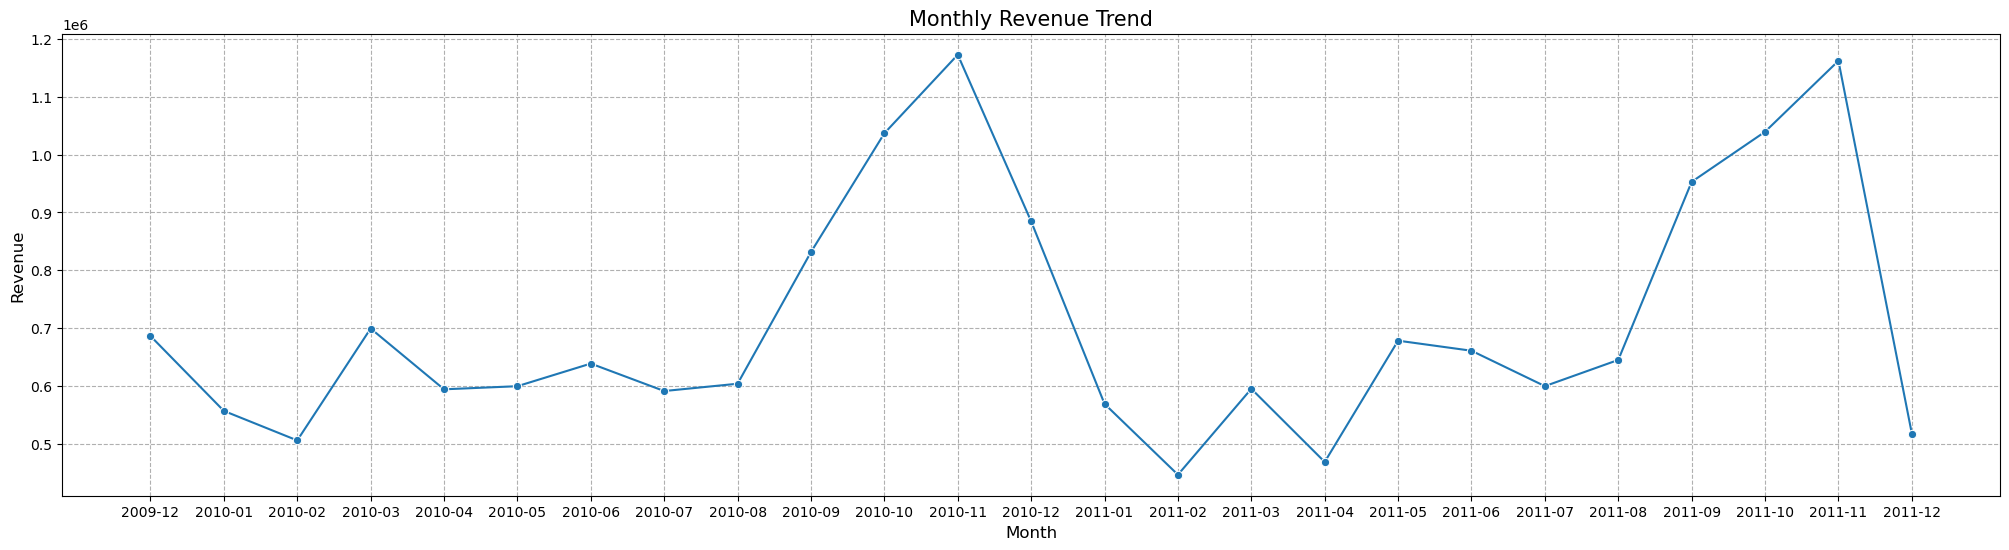

In [89]:
plt.figure(figsize=(25,6))

sns.lineplot(data = monthly_revenue, x = 'Month_Year', y = 'TotalPrice', marker = 'o')
plt.title('Monthly Revenue Trend', fontsize = 15)
plt.xlabel('Month', fontsize = 12),
plt.ylabel('Revenue', fontsize = 12),
plt.grid(True, linestyle = "--")
plt.show()

In [90]:
highest_month = monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmax()]
lowest_month = monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmin()]

print(f"Highest Revenue: {highest_month['Month_Year']} with ${highest_month['TotalPrice']:,.2f}")
print(f"Lowest Revenue: {lowest_month['Month_Year']} with ${lowest_month['TotalPrice']:,.2f}")

Highest Revenue: 2010-11 with $1,172,336.04
Lowest Revenue: 2011-02 with $447,137.35


#### The plot shows that the revenue was going up in the period from 08/2010 till 11/2010 and then same again in the next year so it tells that the revenue is mostly high in the last quater of the year 

In [91]:
top_10_countries = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10).reset_index()

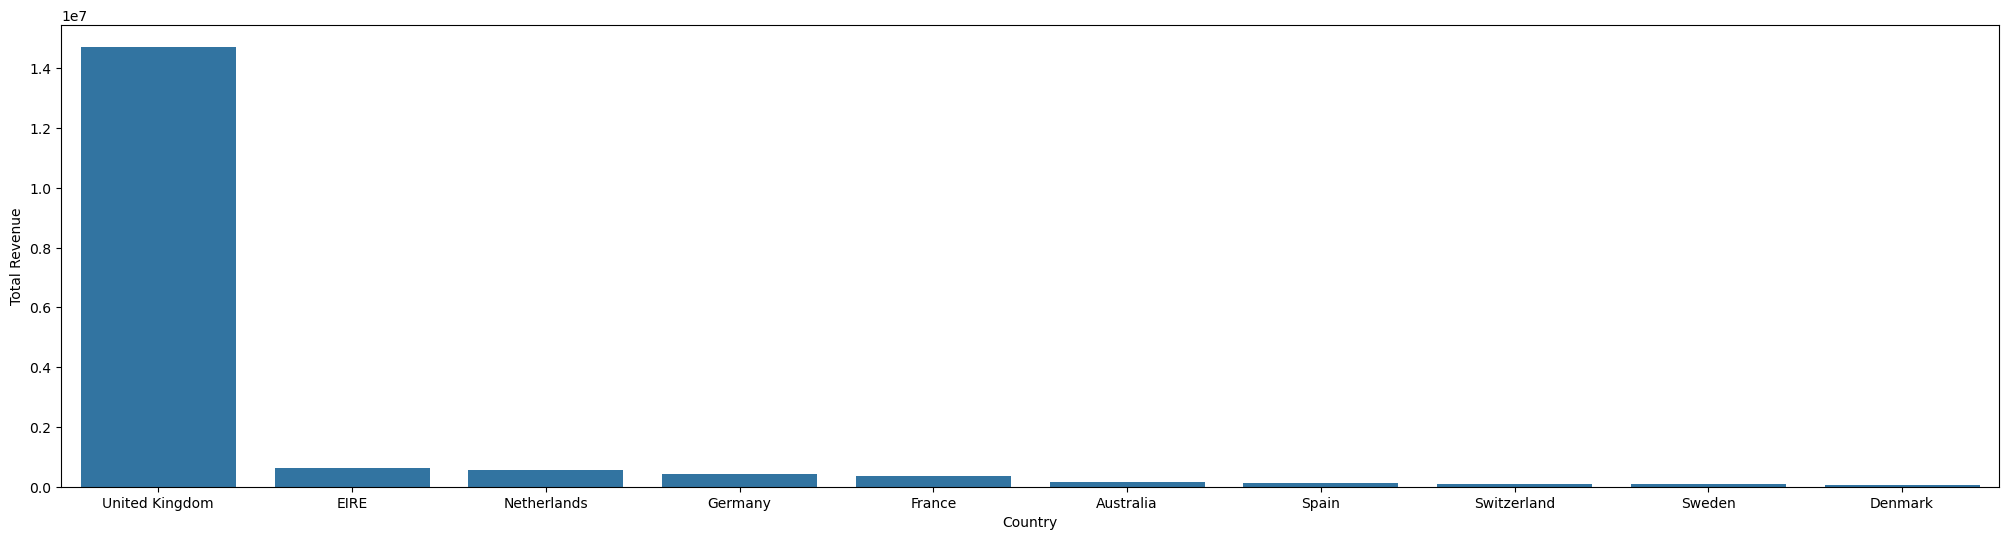

In [92]:
plt.figure(figsize=(25,6))

sns.barplot(data = top_10_countries, x = 'Country', y = 'TotalPrice')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.show()

In [93]:
total_revenue = df_clean['TotalPrice'].sum()

uk_revenue = df_clean[df_clean['Country'] == 'United Kingdom']['TotalPrice'].sum()

uk_percentage = (uk_revenue / total_revenue) * 100

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"UK Revenue: ${uk_revenue:,.2f}")
print(f"Percentage of revenue from UK: {uk_percentage:.2f}%")

Total Revenue: $17,743,429.18
UK Revenue: $14,723,147.52
Percentage of revenue from UK: 82.98%


#### Here we get the picture that the UK is the most revenue generating country compared to other countries 

In [94]:
customer_vise_spent = df_clean.groupby('Customer ID')['TotalPrice'].sum()

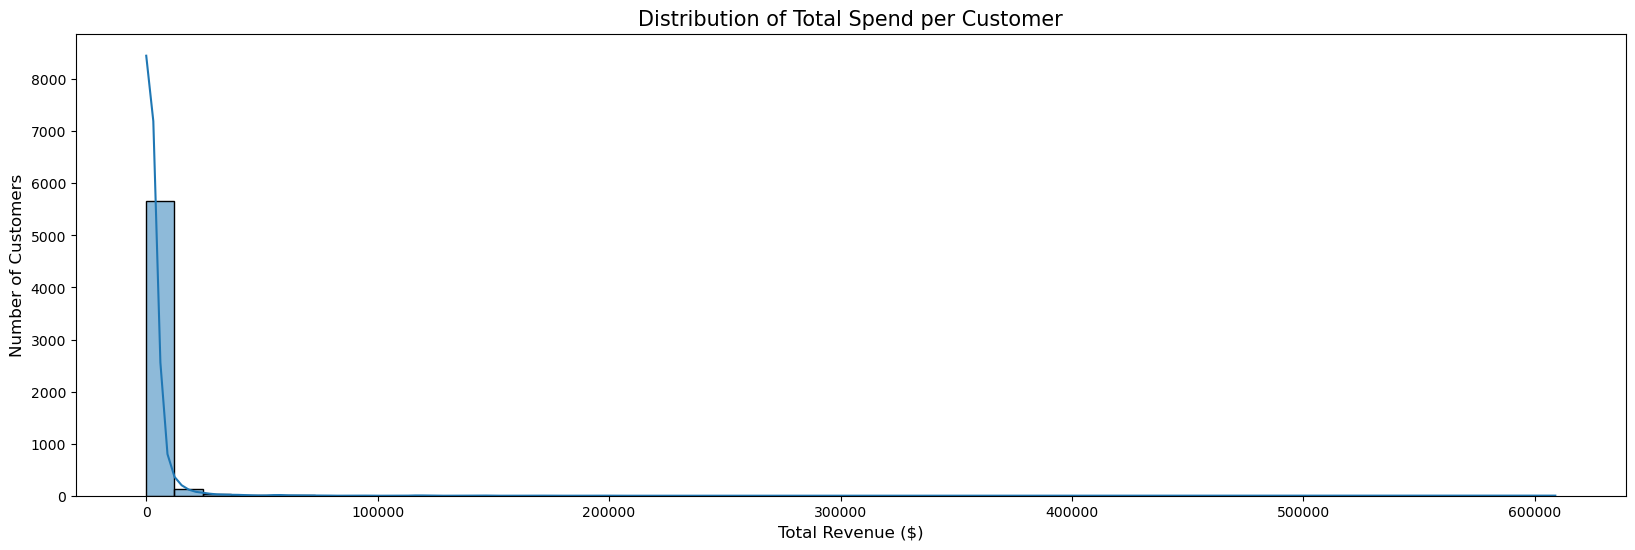

In [95]:
plt.figure(figsize=(20,6))

sns.histplot(customer_vise_spent, bins = 50, kde = True)
plt.title('Distribution of Total Spend per Customer', fontsize=15)
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

#### We can see there are very few customers which give the revenue of over 400000 and mostly customers the customer have zero revenue 

In [96]:
print(customer_vise_spent.describe())
print(f"% customers under $5000: {(customer_vise_spent < 5000).sum() / len(customer_vise_spent) * 100:.1f}%")

count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: TotalPrice, dtype: float64
% customers under $5000: 88.6%


Number of invoices per customer (histogram)

In [97]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Month_Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [98]:
invoice_per_customer = df_clean.groupby("Customer ID")["Invoice"].nunique()

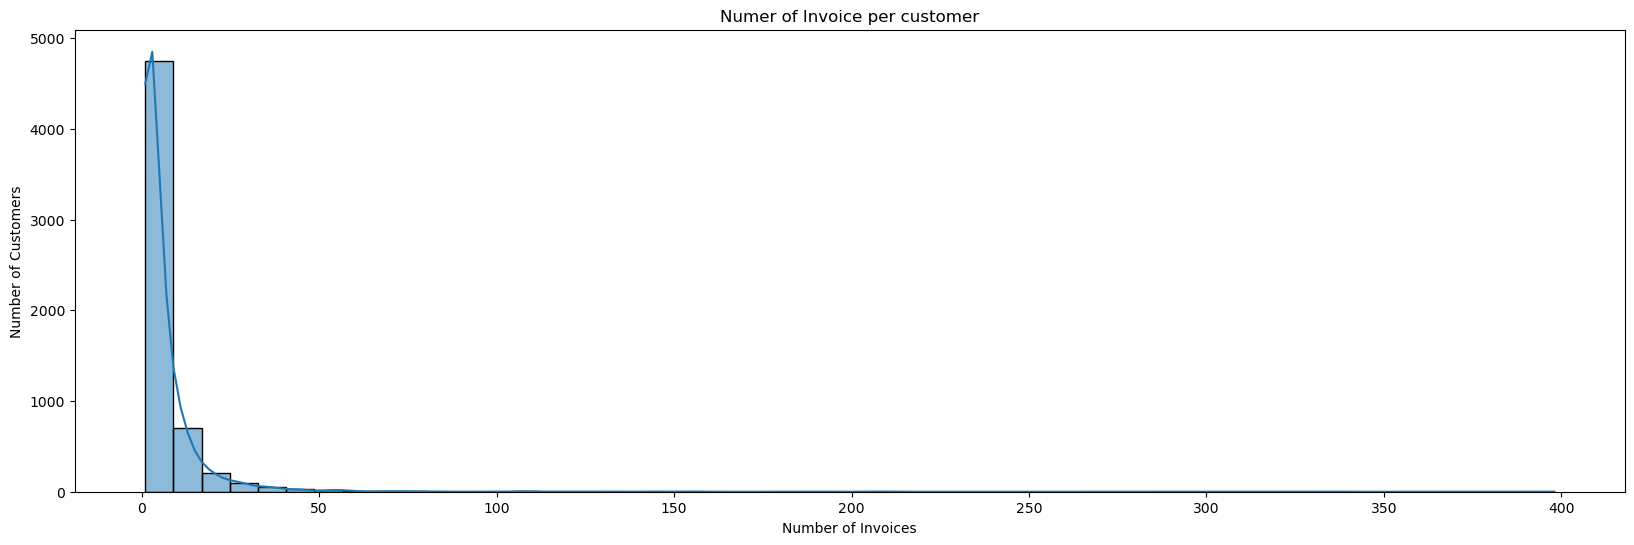

In [99]:
plt.figure(figsize=(20,6))

sns.histplot(invoice_per_customer, bins = 50, kde = True)
plt.title('Numer of Invoice per customer')
plt.xlabel('Number of Invoices')
plt.ylabel('Number of Customers')
plt.show()

In [100]:
total_customers = len(invoice_per_customer)

In [101]:
total_customers

5878

In [102]:
one_purchase_customers = (invoice_per_customer == 1).sum()

In [103]:
one_purchase_customers

1623

In [104]:
pct_one_purchase = (one_purchase_customers / total_customers) * 100

In [105]:
pct_one_purchase

27.611432460020414

In [106]:
print(f"Total Customers: {total_customers}")
print(f"Customers with only 1 purchase: {one_purchase_customers}")
print(f"Percentage of customers who made only 1 purchase: {pct_one_purchase:.2f}%")

Total Customers: 5878
Customers with only 1 purchase: 1623
Percentage of customers who made only 1 purchase: 27.61%


In [107]:
# Top 10 customers by revenue
# Bottom 10 customers by revenue (excluding returns already cleaned)
# Print: Revenue gap between top customer and median customer

In [108]:
top_10_customer_by_revenue = df_clean.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
bottom_10_customer_by_revenue = df_clean.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).tail(10)

In [109]:
top_10_customer_by_revenue

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64

In [110]:
bottom_10_customer_by_revenue

Customer ID
16878.0    13.30
17956.0    12.75
17378.0    10.95
18115.0     9.70
15040.0     7.49
15913.0     6.30
14792.0     6.20
16738.0     3.75
13788.0     3.75
14095.0     2.95
Name: TotalPrice, dtype: float64

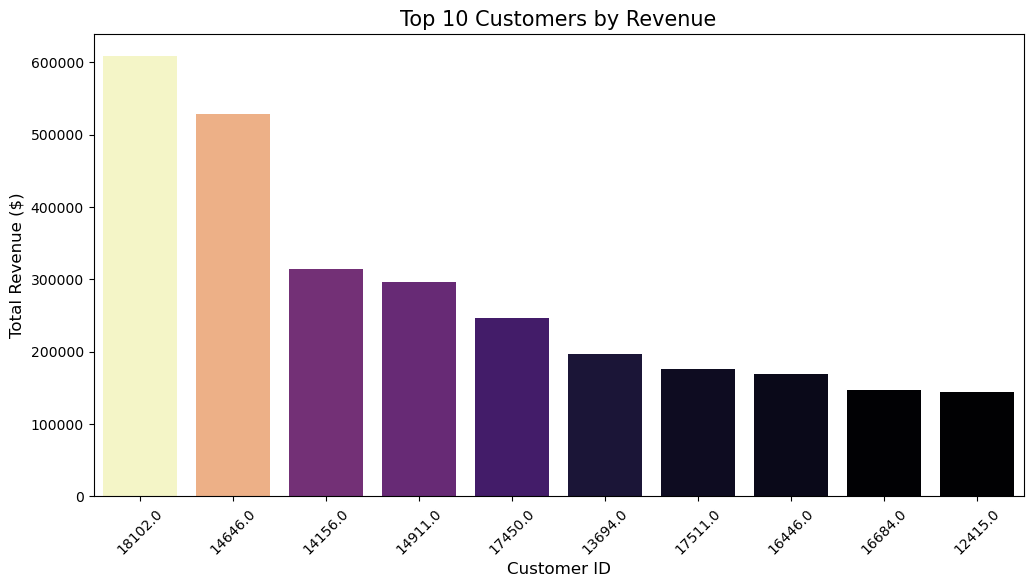

In [111]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_customer_by_revenue.index.astype(str), 
            y=top_10_customer_by_revenue.values, 
            palette='magma', hue = top_10_customer_by_revenue, legend = False)

plt.title('Top 10 Customers by Revenue', fontsize=15)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [112]:
all_customer_spend = df_clean.groupby('Customer ID')['TotalPrice'].sum()

top_customer_value = all_customer_spend.max()
median_customer_value = all_customer_spend.median()

revenue_gap = top_customer_value - median_customer_value
multiplier = top_customer_value / median_customer_value

print(f"Top Customer Revenue: ${top_customer_value:,.2f}")
print(f"Median Customer Revenue: ${median_customer_value:,.2f}")
print("-" * 30)
print(f"The Revenue Gap is: ${revenue_gap:,.2f}")
print(f"The top customer spends {multiplier:.1f}x more than the median customer.")

Top Customer Revenue: $608,821.65
Median Customer Revenue: $898.91
------------------------------
The Revenue Gap is: $607,922.73
The top customer spends 677.3x more than the median customer.


In [113]:
import datetime

snapshot_date = df_clean['InvoiceDate'].max() + datetime.timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalPrice', 'sum')
).reset_index()

print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


In [114]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print(rfm[['Customer ID','Recency','Frequency','Monetary','R_Score','F_Score','M_Score','RFM_Score']].head(10))

   Customer ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0      12346.0      326         12  77556.46       2       4       4       244
1      12347.0        2          8   5633.32       4       4       4       444
2      12348.0       75          5   2019.40       3       3       3       333
3      12349.0       19          4   4428.69       4       3       4       434
4      12350.0      310          1    334.40       2       1       1       211
5      12351.0      375          1    300.93       2       1       1       211
6      12352.0       36         10   2849.84       3       4       4       344
7      12353.0      204          2    406.76       2       2       2       222
8      12354.0      232          1   1079.40       2       1       3       213
9      12355.0      214          2    947.61       2       2       3       223


In [115]:
def assign_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r == 4 and f == 4 and m == 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r == 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r == 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cant Lose Them'
    elif r == 1:
        return 'Lost'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)
print(rfm['Segment'].value_counts())
print(f"\nTotal customers: {len(rfm)}")

Segment
Loyal Customers    1398
Lost               1332
Hibernating         669
Champions           661
At Risk             654
Promising           558
New Customers       336
Cant Lose Them      270
Name: count, dtype: int64

Total customers: 5878


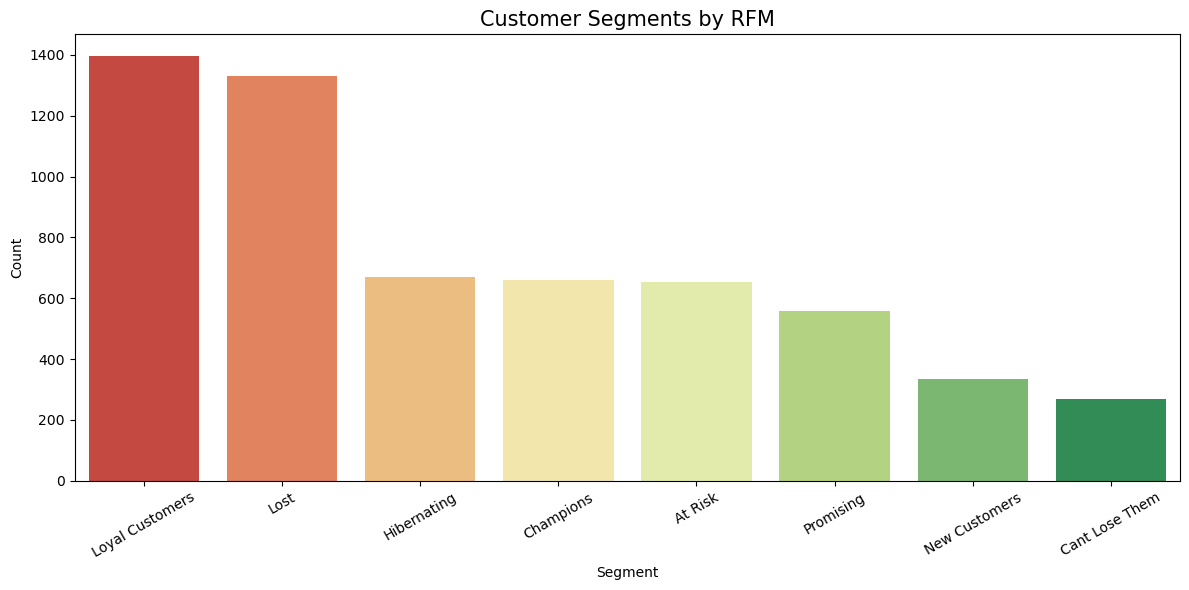

In [118]:
seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

plt.figure(figsize=(12,6))
sns.barplot(data=seg_counts, x='Segment', y='Count', palette='RdYlGn', hue = 'Segment')
plt.title('Customer Segments by RFM', fontsize=15)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [119]:
seg_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
print("\nRevenue by Segment:")
print(seg_revenue.round(2))


Revenue by Segment:
Segment
Champions          9629444.41
Loyal Customers    3987023.14
At Risk            1767264.26
Lost                790094.01
Cant Lose Them      558643.21
Promising           385828.79
New Customers       384124.38
Hibernating         241006.97
Name: Monetary, dtype: float64


In [120]:
rfm['Churned'] = (rfm['Recency'] > 180).astype(int)

print(rfm['Churned'].value_counts())
print(f"\nChurn Rate: {rfm['Churned'].mean()*100:.1f}%")

Churned
0    3478
1    2400
Name: count, dtype: int64

Churn Rate: 40.8%


In [133]:
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churned']

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [135]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [136]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [137]:
lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:,1]

In [138]:
print("______________________Logistic Regression_______________________")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.3f}")

______________________Logistic Regression_______________________
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       696
           1       0.67      0.69      0.68       480

    accuracy                           0.73      1176
   macro avg       0.72      0.72      0.72      1176
weighted avg       0.73      0.73      0.73      1176

ROC-AUC: 0.779


In [139]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [140]:
rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:,1]

In [141]:
print("______________________Random Forest_______________________")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.3f}")

______________________Random Forest_______________________
              precision    recall  f1-score   support

           0       0.67      0.67      0.67       696
           1       0.52      0.52      0.52       480

    accuracy                           0.61      1176
   macro avg       0.59      0.59      0.59      1176
weighted avg       0.61      0.61      0.61      1176

ROC-AUC: 0.673


In [143]:
threshold = 0.4
lr_preds_tuned = (lr_probs >= threshold).astype(int)

In [146]:
print(f"_______________________ LR at threshold {threshold} _________________________")
print(classification_report(y_test, lr_preds_tuned))

_______________________ LR at threshold 0.4 _________________________
              precision    recall  f1-score   support

           0       0.83      0.53      0.65       696
           1       0.55      0.84      0.67       480

    accuracy                           0.66      1176
   macro avg       0.69      0.69      0.66      1176
weighted avg       0.72      0.66      0.66      1176



In [147]:
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_probs)

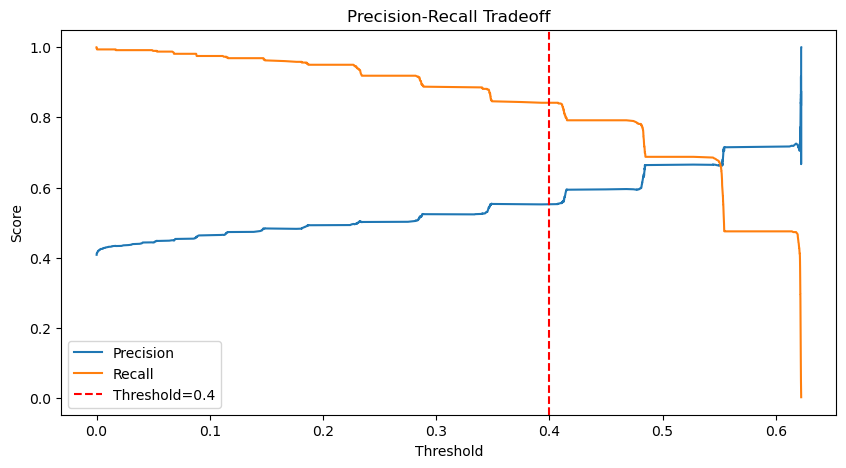

In [148]:
plt.figure(figsize=(10,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.4, color='red', linestyle='--', label='Threshold=0.4')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff')
plt.legend()
plt.show()

In [151]:
rfm.to_csv(r'D:\Learning\Projects\E-commerce_customer_Churn_analysis\outputs/rfm_segments.csv', index=False)

monthly_revenue.to_csv(r'D:\Learning\Projects\E-commerce_customer_Churn_analysis\outputs/monthly_revenue.csv', index=False)

country_revenue = df_clean.groupby('Country')['TotalPrice'].sum().reset_index()
country_revenue.to_csv(r'D:\Learning\Projects\E-commerce_customer_Churn_analysis\outputs/country_revenue.csv', index=False)

df_clean.to_csv(r'D:\Learning\Projects\E-commerce_customer_Churn_analysis\outputs/df_clean.csv', index=False)